# FraudLens: Exploratory Data Analysis

**Question:** which signals separate fraudulent card transactions from legitimate ones, and what
does that mean for modelling?

**Scope (no peeking):** every analysis uses the **train split only** (fraudTrain up to
2020-04-21, 1,145,597 transactions). Validation is kept clean for model selection and the test
set is never loaded. The one exception is the fraud-rate-over-time chart, which adds the
validation months to show drift.

**Data:** `data/processed/features.parquet` from `fraudlens build-features`; only the needed
columns are read. Every chart is followed by a short business takeaway.

Outputs are saved in the notebook. To re-run: open it in VS Code, pick the project's `.venv`
kernel, and Run All (about 20 seconds, under 1 GB of memory).

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

from fraudlens.config import load_config
from fraudlens.data.splits import load_features
from fraudlens.features.feature_names import label

# Chart style: validated palette (legit = blue, fraud = orange), recessive grid and axes.
LEGIT, FRAUD, QUIET = "#2a78d6", "#eb6834", "#b4b2ac"
INK, INK2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e6e5e1", "#fcfcfb"
plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "figure.dpi": 110,
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.edgecolor": QUIET,
        "axes.labelcolor": INK2,
        "text.color": INK,
        "xtick.color": INK2,
        "ytick.color": INK2,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "axes.grid.axis": "y",
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
        "legend.frameon": False,
    }
)
pct = mtick.PercentFormatter(xmax=1, decimals=1)

COLUMNS = [
    "is_fraud",
    "cc_num",
    "amt",
    "category",
    "hour",
    "is_night",
    "age_at_txn",
    "distance_km",
    "card_txn_count_1h",
    "card_txn_count_24h",
    "card_amt_sum_24h",
    "amt_to_card_avg_ratio",
    "secs_since_last_txn",
    "is_new_category_for_card",
]
config = load_config()
df = load_features(config, columns=COLUMNS, splits=("train",))
BASE = df["is_fraud"].mean()


def fraud_rate(data: pd.DataFrame, by) -> pd.DataFrame:
    # Transactions, fraud count, fraud rate and lift (rate / overall rate) per group.
    out = data.groupby(by, observed=True)["is_fraud"].agg(
        transactions="size", fraud="sum", rate="mean"
    )
    out["lift"] = out["rate"] / BASE
    return out


def show(table: pd.DataFrame) -> None:
    # Print a rate table with readable percentages.
    print(
        table[["transactions", "fraud", "rate"]]
        .assign(rate=table["rate"].map("{:.2%}".format))
        .to_string()
    )


def base_line(ax, horizontal=False):
    # Dashed reference at the overall fraud rate.
    kw = dict(color=INK2, linestyle="--", linewidth=1)
    (ax.axvline if horizontal else ax.axhline)(BASE, **kw)


print(
    f"{len(df):,} train transactions, {df.shape[1]} columns, {df.memory_usage(deep=True).sum() / 2**20:.0f} MB"
)

1,145,597 train transactions, 17 columns, 80 MB


## 1. Class imbalance

In [2]:
summary = pd.DataFrame(
    {
        "transactions": [len(df)],
        "fraud": [int(df["is_fraud"].sum())],
        "fraud rate": [f"{BASE:.3%}"],
        "1 fraud in every": [f"{1 / BASE:,.0f} transactions"],
        "accuracy of 'never fraud'": [f"{1 - BASE:.2%}"],
    },
    index=["train split"],
)
summary

,transactions,fraud,fraud rate,1 fraud in every,accuracy of 'never fraud'
train split,1145597,6558,0.572%,175 transactions,99.43%


**Takeaway:** fraud is about **1 in 175 transactions (0.57%)**. A model that never flags fraud
is 99.43% accurate and completely useless, so accuracy is meaningless here. Models will be
compared on **PR-AUC** and on **business cost**, and class weighting is needed in training.

## 2. Fraud by hour of day

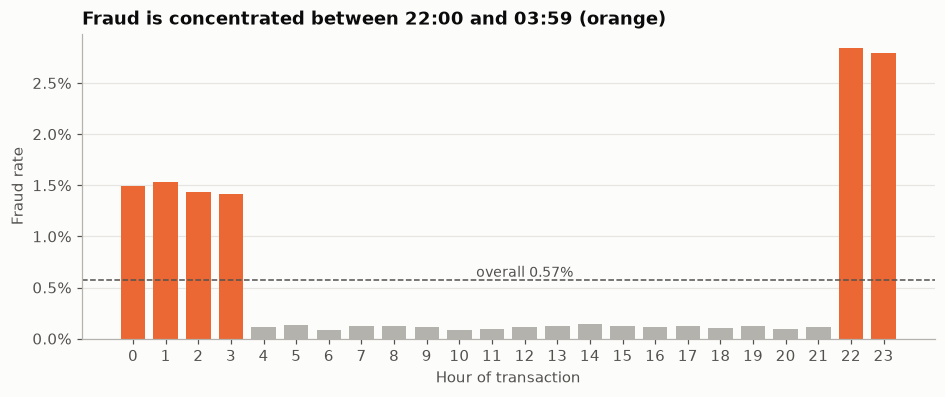

Hours 22:00-03:59 hold 24% of transactions but 85% of fraud.
      transactions  fraud   rate
hour                            
22           59187   1681  2.84%
23           59303   1655  2.79%
0            37544    562  1.50%
1            37951    582  1.53%
2            37543    540  1.44%
3            37717    534  1.42%
4            37036     42  0.11%
12           57582     63  0.11%


In [3]:
by_hour = fraud_rate(df, "hour")
fraud_hours = [22, 23, 0, 1, 2, 3]  # every hour above 2x the overall rate
fig, ax = plt.subplots(figsize=(10, 3.6))
colors = [FRAUD if h in fraud_hours else QUIET for h in by_hour.index]
ax.bar(by_hour.index, by_hour["rate"], color=colors, width=0.75)
base_line(ax)
ax.text(12, BASE, f"overall {BASE:.2%}", va="bottom", ha="center", color=INK2, fontsize=9)
ax.yaxis.set_major_formatter(pct)
ax.set_xticks(range(24))
ax.set_xlabel("Hour of transaction")
ax.set_ylabel("Fraud rate")
ax.set_title("Fraud is concentrated between 22:00 and 03:59 (orange)")
plt.show()

night = df["hour"].isin(fraud_hours)
print(
    f"Hours 22:00-03:59 hold {night.mean():.0%} of transactions but {df.loc[night, 'is_fraud'].sum() / df['is_fraud'].sum():.0%} of fraud."
)
show(by_hour.loc[[22, 23, 0, 1, 2, 3, 4, 12]])

**Takeaway:** **22:00 to 23:59 has a 2.8% fraud rate (about 5x the overall rate)** and
00:00 to 03:59 about 1.5%; every other hour sits near 0.1%. These six hours hold 24% of
transactions but 85% of fraud. The engineered `is_night` flag (22:00 to 05:59) is slightly too
wide, since 04:00 and 05:00 are low-risk; tree models can use the raw `hour` directly.

## 3. Fraud by merchant category

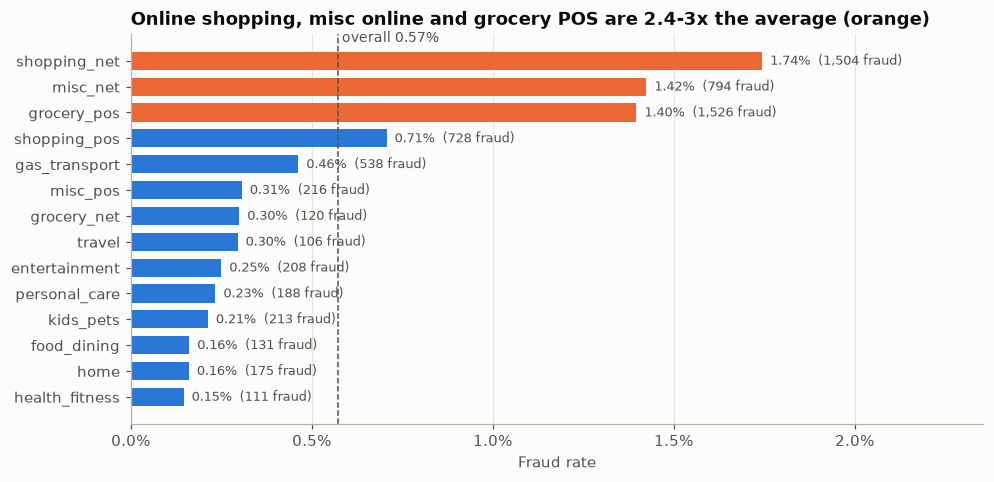

In [4]:
by_cat = fraud_rate(df, "category").sort_values("rate")
fig, ax = plt.subplots(figsize=(10, 4.6))
colors = [FRAUD if r > 2 * BASE else LEGIT for r in by_cat["rate"]]
ax.barh(by_cat.index.astype(str), by_cat["rate"], color=colors, height=0.7)
base_line(ax, horizontal=True)
ax.text(BASE, len(by_cat) - 0.4, f" overall {BASE:.2%}", va="bottom", color=INK2, fontsize=9)
for y, (r, n) in enumerate(zip(by_cat["rate"], by_cat["fraud"], strict=True)):
    ax.text(r, y, f"  {r:.2%}  ({n:,} fraud)", va="center", fontsize=8.5, color=INK2)
ax.xaxis.set_major_formatter(pct)
ax.grid(axis="x")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, by_cat["rate"].max() * 1.35)
ax.set_xlabel("Fraud rate")
ax.set_title("Online shopping, misc online and grocery POS are 2.4-3x the average (orange)")
plt.show()

**Takeaway:** **`shopping_net` (1.74%), `misc_net` (1.42%) and `grocery_pos` (1.40%)** run at
2.4 to 3 times the average, and together hold 58% of all fraud; health, home and dining sit
near 0.15%. Category is a strong feature, and the high-risk mix is plausible: online
"card-not-present" purchases are the classic fraud channel.

## 4. Amount: fraud vs legitimate

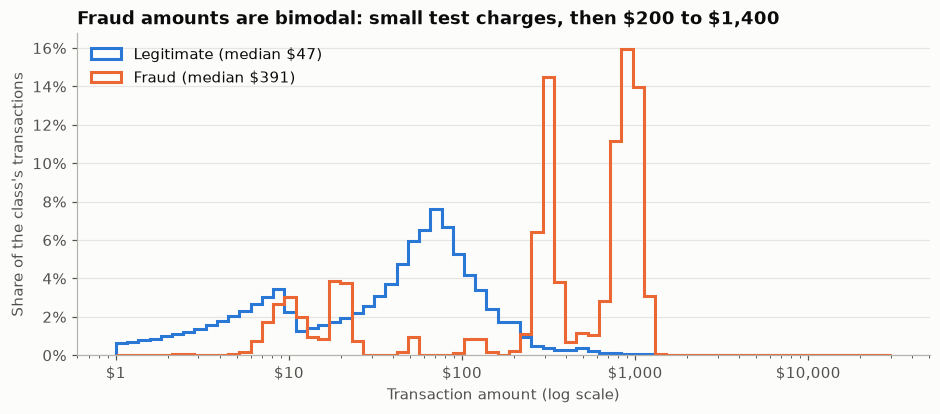

                  transactions  fraud    rate
amt                                          
(0.0, 10.0]             296754    462   0.16%
(10.0, 50.0]            297559    946   0.32%
(50.0, 100.0]           343780     39   0.01%
(100.0, 200.0]          152731    131   0.09%
(200.0, 300.0]           27979    699   2.50%
(300.0, 500.0]           13022   1101   8.45%
(500.0, 800.0]            7458    813  10.90%
(800.0, 1000.0]           2852   1528  53.58%
(1000.0, 1500.0]          2326    839  36.07%
(1500.0, inf]             1136      0   0.00%


In [5]:
bins = np.logspace(0, np.log10(30_000), 70)
fig, ax = plt.subplots(figsize=(10, 3.8))
for value, color, name in [(0, LEGIT, "Legitimate"), (1, FRAUD, "Fraud")]:
    amounts = df.loc[df["is_fraud"] == value, "amt"]
    # Each bin's share of that class's transactions (not density: bins widen on a log axis).
    ax.hist(
        amounts,
        bins=bins,
        weights=np.full(len(amounts), 1 / len(amounts)),
        histtype="step",
        linewidth=2,
        color=color,
        label=rf"{name} (median \${amounts.median():,.0f})",
    )
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: rf"\${v:,.0f}"))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel("Transaction amount (log scale)")
ax.set_ylabel("Share of the class's transactions")
ax.legend(loc="upper left")
ax.set_title(r"Fraud amounts are bimodal: small test charges, then \$200 to \$1,400")
plt.show()

bands = pd.cut(df["amt"], [0, 10, 50, 100, 200, 300, 500, 800, 1000, 1500, np.inf])
show(fraud_rate(df, bands))

## 5. Spending and velocity relative to the card's own history

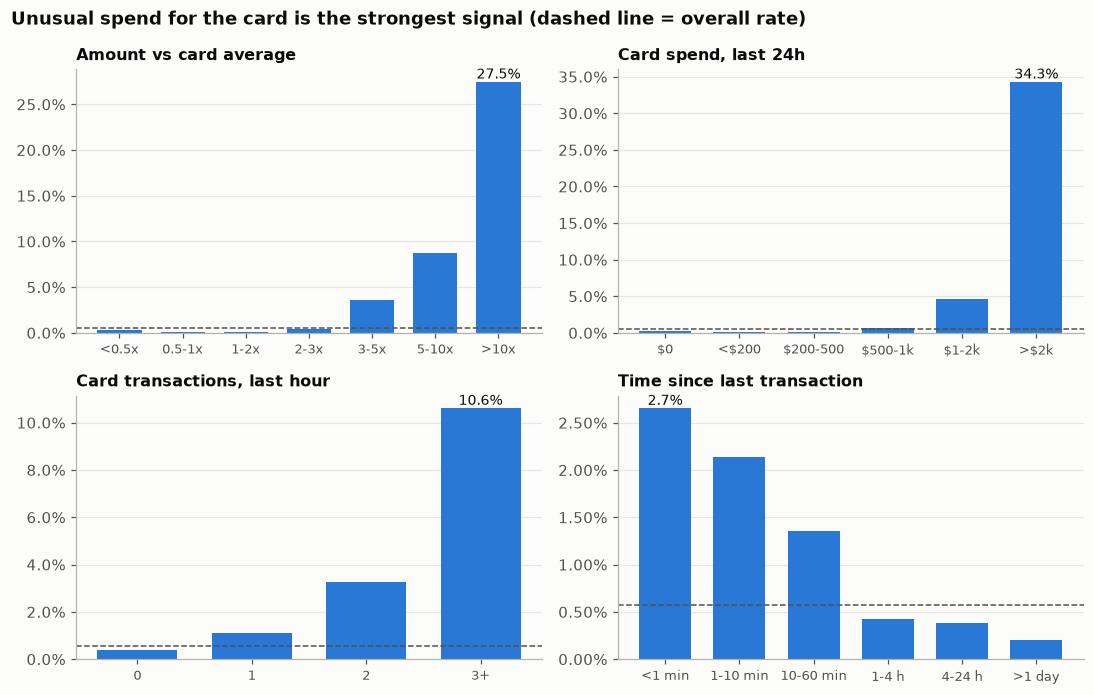

In [6]:
panels = [
    (
        "amt_to_card_avg_ratio",
        [0, 0.5, 1, 2, 3, 5, 10, np.inf],
        ["<0.5x", "0.5-1x", "1-2x", "2-3x", "3-5x", "5-10x", ">10x"],
    ),
    (
        "card_amt_sum_24h",
        [-1, 0, 200, 500, 1000, 2000, np.inf],
        [r"\$0", r"<\$200", r"\$200-500", r"\$500-1k", r"\$1-2k", r">\$2k"],
    ),
    ("card_txn_count_1h", [-1, 0, 1, 2, np.inf], ["0", "1", "2", "3+"]),
    (
        "secs_since_last_txn",
        [-1, 60, 600, 3600, 4 * 3600, 86400, np.inf],
        ["<1 min", "1-10 min", "10-60 min", "1-4 h", "4-24 h", ">1 day"],
    ),
]
fig, axes = plt.subplots(2, 2, figsize=(10, 6.4))
for ax, (col, edges, names) in zip(axes.flat, panels, strict=True):
    t = fraud_rate(df, pd.cut(df[col], edges, labels=names))
    ax.bar(range(len(t)), t["rate"], color=LEGIT, width=0.7)
    top = int(np.argmax(t["rate"].to_numpy()))
    ax.text(
        top, t["rate"].iloc[top], f"{t['rate'].iloc[top]:.1%}", ha="center", va="bottom", fontsize=9
    )
    base_line(ax)
    ax.set_xticks(range(len(t)), t.index.astype(str), fontsize=8.5)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_title(label(col), fontsize=10.5)
fig.suptitle(
    "Unusual spend for the card is the strongest signal (dashed line = overall rate)",
    x=0.01,
    ha="left",
    fontweight="bold",
    fontsize=12,
)
fig.tight_layout()
plt.show()

**Takeaway:** the features that compare a transaction with **the card's own history** separate
fraud far better than any raw attribute. An amount **more than 10x the card's average is 27%
fraud** (48x the overall rate); a card that has spent **over $2,000 in the past 24 hours is at
34%**; **3+ transactions in the past hour, 11%**; a transaction **within a minute** of the previous
one, 2.6%. This is the payoff of the per-card SQL features from Phase 2, and the reason the
API must keep card state online.

## 6. Age and distance

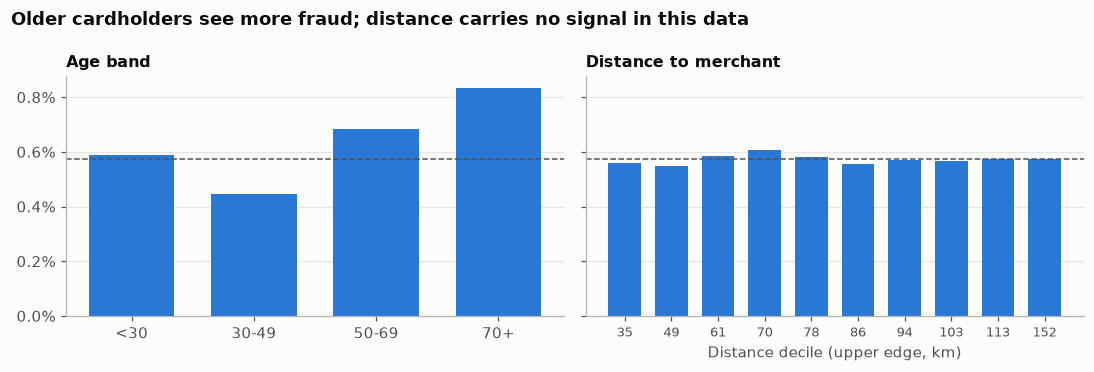

            transactions  fraud   rate
age_at_txn                            
<30               217141   1281  0.59%
30-49             526155   2352  0.45%
50-69             283204   1931  0.68%
70+               119097    994  0.83%


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
age = fraud_rate(
    df,
    pd.cut(
        df["age_at_txn"], [0, 30, 50, 70, 200], right=False, labels=["<30", "30-49", "50-69", "70+"]
    ),
)
ax1.bar(range(len(age)), age["rate"], color=LEGIT, width=0.7)
ax1.set_xticks(range(len(age)), age.index.astype(str))
ax1.set_title("Age band", fontsize=10.5)
dist = fraud_rate(df, pd.qcut(df["distance_km"], 10))
ax2.bar(range(len(dist)), dist["rate"], color=LEGIT, width=0.7)
ax2.set_xticks(range(len(dist)), [f"{iv.right:.0f}" for iv in dist.index], fontsize=8.5)
ax2.set_xlabel("Distance decile (upper edge, km)")
ax2.set_title("Distance to merchant", fontsize=10.5)
for ax in (ax1, ax2):
    base_line(ax)
    ax.yaxis.set_major_formatter(pct)
fig.suptitle(
    "Older cardholders see more fraud; distance carries no signal in this data",
    x=0.01,
    ha="left",
    fontweight="bold",
    fontsize=12,
)
fig.tight_layout()
plt.show()
show(age)

**Takeaway:** fraud rises with age, from **0.45% for 30-49 to 0.83% for 70+** (1.8x), which makes
age a useful feature but also a fairness question: the Phase 7 audit will check whether the
model's errors fall unevenly across age bands. **Distance shows no signal**: every decile sits
between 0.55% and 0.61%. In the simulator, merchants are placed at random near the cardholder
whether or not the transaction is fraud, so this realistic feature is uninformative here. It
stays in the feature set (real data would likely use it), and we expect the model to ignore it.

## 7. Fraud rate over time

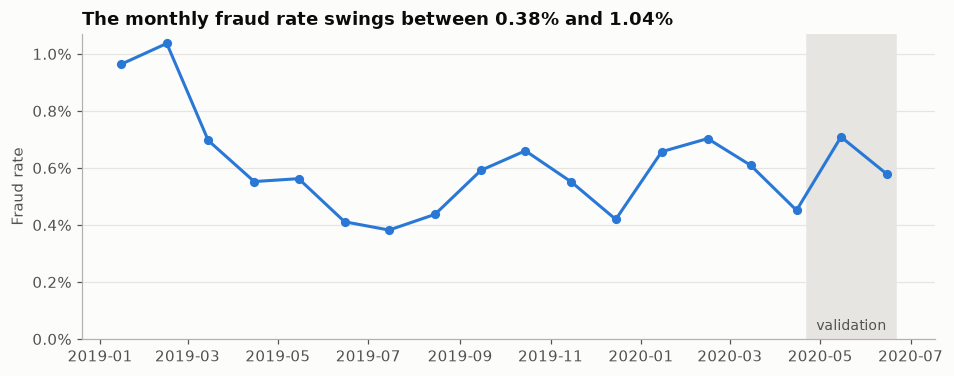

In [8]:
dev = load_features(config, columns=["is_fraud"], splits=("train", "validation"))
monthly = dev.groupby(dev["trans_ts"].dt.to_period("M"))["is_fraud"].mean()
months = monthly.index.to_timestamp() + pd.Timedelta(days=14)  # plot at mid-month
fig, ax = plt.subplots(figsize=(10, 3.6))
val_start, val_end = (
    pd.Timestamp(config.split.train_end) + pd.Timedelta(days=1),
    pd.Timestamp(config.split.validation_end),
)
ax.axvspan(val_start, val_end, color=GRID, zorder=0)
ax.text(
    val_start + (val_end - val_start) / 2,
    0.0002,
    "validation",
    ha="center",
    va="bottom",
    color=INK2,
    fontsize=9,
)
ax.plot(months, monthly.to_numpy(), color=LEGIT, linewidth=2, marker="o", markersize=5)
ax.yaxis.set_major_formatter(pct)
ax.set_ylim(0, None)
ax.set_ylabel("Fraud rate")
ax.set_title("The monthly fraud rate swings between 0.38% and 1.04%")
plt.show()

**Takeaway:** the fraud rate is not stable: **1.0% in January-February 2019, 0.38% in July 2019,
and 0.42% in December 2019**, when transaction volume doubles for the holidays (fraud counts
rise, but less than spending). The validation months (late April-June 2020) run slightly above
the training average (0.63% vs 0.57%). A model trained on one period will meet a different base
rate in production, so the threshold and calibration must be monitored; this is the drift story
for Phase 9.

## 8. Fraud comes in bursts on the same card

In [9]:
per_card = df[df["is_fraud"] == 1].groupby("cc_num").size()
print(
    f"{per_card.size} of {df['cc_num'].nunique()} cards had fraud in the train period; "
    f"median {per_card.median():.0f} fraud transactions per affected card (range {per_card.min()}-{per_card.max()})."
)
new_cat = fraud_rate(df, "is_new_category_for_card")
print(
    f"First use of a category on a card: {new_cat.loc[1, 'rate']:.2%} fraud vs {new_cat.loc[0, 'rate']:.2%} otherwise."
)

663 of 971 cards had fraud in the train period; median 10 fraud transactions per affected card (range 2-19).
First use of a category on a card: 3.09% fraud vs 0.54% otherwise.


**Takeaway:** fraud arrives as **episodes**: a compromised card typically sees about 10 fraudulent
transactions in a short burst, rather than isolated events. This explains why the velocity and
24-hour spend features work, and it is another reason the split must be by time: a random split
would put half of one burst in training and half in testing, letting the model "remember" the
episode and overstating its performance.

## Five most important findings

1. **Fraud is rare: 0.57% (1 in 175).** Accuracy is meaningless; use PR-AUC and business cost,
   and weight the minority class.
2. **Card-relative features are the strongest signals.** Amount over 10x the card's average is
   27% fraud; over $2,000 spent in 24 hours, 34%; 3+ transactions in an hour, 11%. Keeping card
   state online in the API is essential.
3. **Fraud happens at night.** 22:00-03:59 holds 85% of fraud but 24% of transactions; 22:00-23:59
   runs at 2.8%.
4. **Amount and category matter, with synthetic artefacts.** Fraud is bimodal (small test
   charges and $200-1,400 purchases; $800-1,000 is 54% fraud), concentrated in online shopping and
   grocery POS. No fraud above $1,500 is a simulator artefact the model will exploit.
5. **Some realistic signals are absent, and the base rate drifts.** Distance carries no signal in
   this simulator; the monthly fraud rate moves between 0.38% and 1.04%, so thresholds need
   monitoring. Fraud also clusters in per-card bursts, which justifies the time-based split.

**Implications for Phase 4:** tree models (XGBoost, LightGBM) should beat logistic regression,
because the strongest effects are non-linear (the hour pattern, amount bands, ratio thresholds).
The logistic baseline will need the missing-history values imputed. Expect very high scores
because the data is synthetic; the value is in the evaluation discipline, not the number.